Total alpha-only return: 0.1231
Total portfolio return: 0.4775
Total OMXS30 return: 0.3113
Total excess return vs OMXS30: 0.1661
Mean monthly alpha-only return: 0.0036
Mean monthly portfolio return: 0.0119
Mean monthly alpha: 0.0036
Sharpe ratio (alpha / std * sqrt(12)): 0.5221
Saved backtest results to /Users/oscarholst/portfolio-optimization-ml/data/02_portfolio_optimization_backtest.xlsx


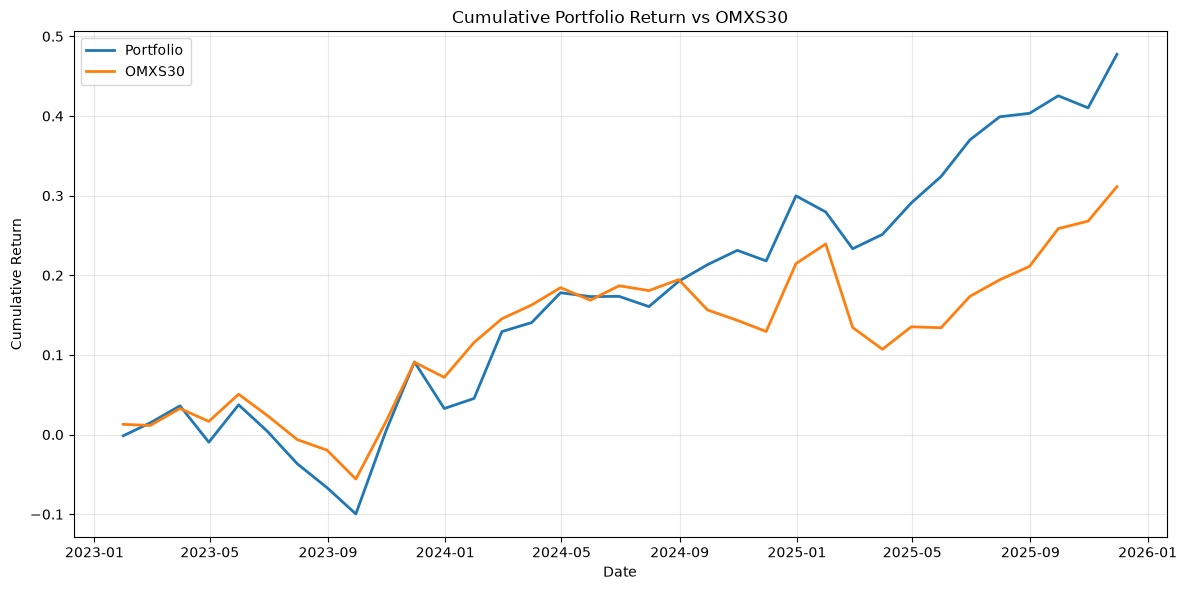

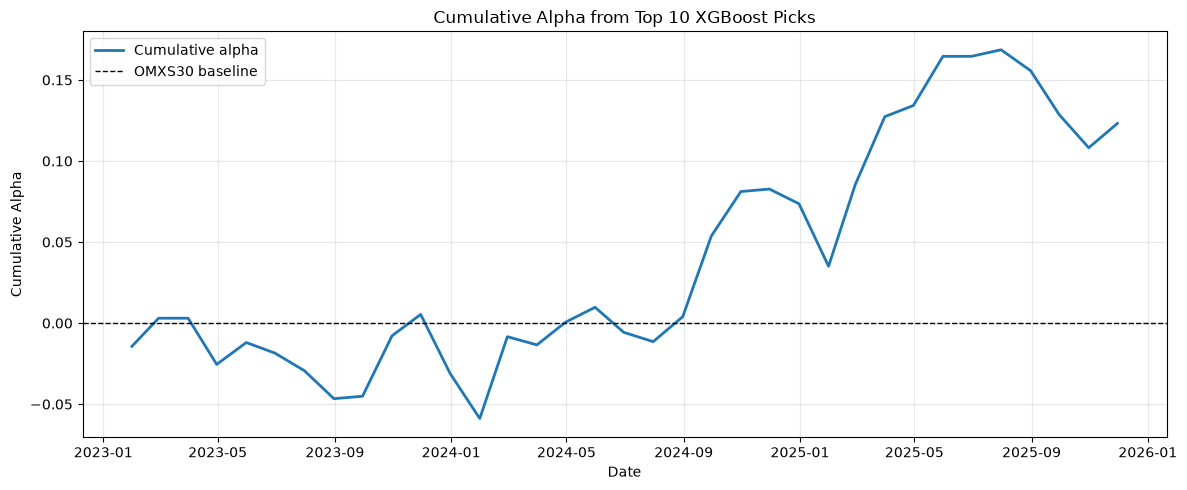

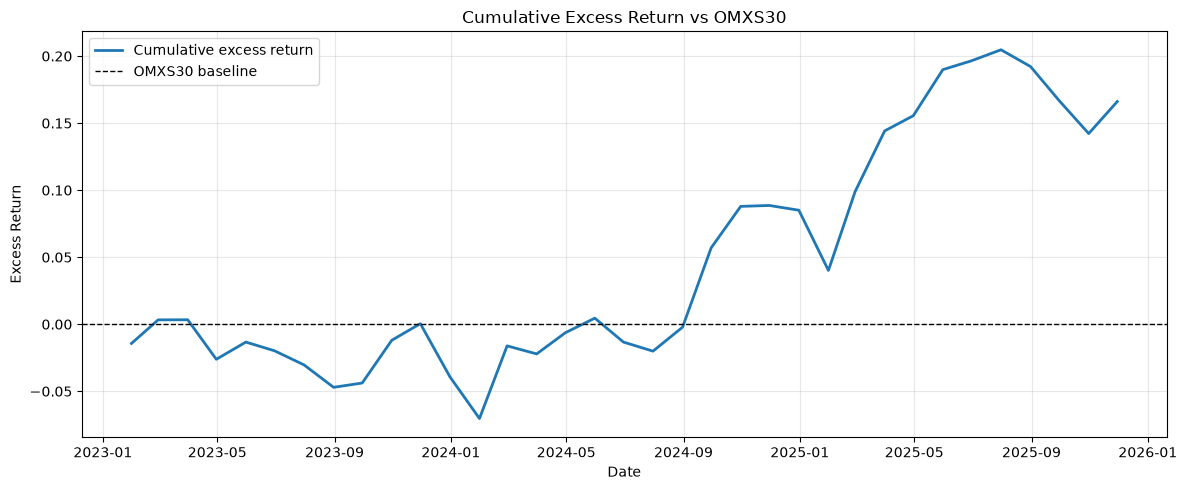

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Berätta för Python att leta i mappen ovanför denna notebook
sys.path.append(os.path.abspath('../'))

from src.data_loader import get_data_path

# Load predictions from the current notebook state if available; otherwise fall back to the exported Excel file.
if "df_predictions" in globals():
    df_backtest = df_predictions.copy()
elif "df_test" in globals():
    df_backtest = df_test.copy()
else:
    df_backtest = pd.read_excel(get_data_path('omxs30_modell_gissningar.xlsx'))

# Make a local copy and ensure clean inputs.
df_backtest["Date"] = pd.to_datetime(df_backtest["Date"])
df_backtest = df_backtest.dropna(
    subset=[
        "Date",
        "Ticker",
        "Target_Next_Month_Relative_Return",
        "XGB_Predicted_Return",
    ]
)

# Try to build the OMXS30 next-month return series from the available notebook state.
if "OMXS30_Next_Month_Return" in df_backtest.columns:
    benchmark_returns = (
        df_backtest.groupby("Date")["OMXS30_Next_Month_Return"].first().sort_index()
    )
elif "df_monthly_global" in globals() and "OMXS30_Index" in df_monthly_global.columns:
    benchmark_returns = (
        df_monthly_global["OMXS30_Index"].pct_change().shift(-1).dropna()
    )
    benchmark_returns.index = pd.to_datetime(benchmark_returns.index)
elif "df_monthly_returns" in globals() and "OMXS30_Index" in df_monthly_returns.columns:
    benchmark_returns = df_monthly_returns["OMXS30_Index"].shift(-1).dropna()
    benchmark_returns.index = pd.to_datetime(benchmark_returns.index)
else:
    try:
        market_data = pd.read_excel(get_data_path('omxs30_och_makrodata.xlsx'))
        market_data["Date"] = pd.to_datetime(market_data["Date"])
        market_data = market_data.sort_values("Date").set_index("Date")
        benchmark_returns = market_data["OMXS30_Index"].pct_change().shift(-1).dropna()
    except Exception as exc:
        raise ValueError(
            "Could not find OMXS30 next-month returns. Add a benchmark return series, df_monthly_global, or the exported omxs30_och_makrodata.xlsx file first."
        ) from exc
    benchmark_returns.index = pd.to_datetime(benchmark_returns.index)

portfolio_rows = []
alpha_rows = []

for date, group in df_backtest.groupby("Date"):
    if date not in benchmark_returns.index:
        continue

    top_10 = group.sort_values("XGB_Predicted_Return", ascending=False).head(10)
    monthly_alpha = top_10["Target_Next_Month_Relative_Return"].mean()
    benchmark_return = benchmark_returns.loc[date]
    monthly_portfolio_return = monthly_alpha + benchmark_return

    portfolio_rows.append(
        {
            "Date": date,
            "Portfolio_Alpha": monthly_alpha,
            "OMXS30_Return": benchmark_return,
            "Portfolio_Return": monthly_portfolio_return,
            "Num_Selected": len(top_10),
        }
    )
    alpha_rows.append(
        {
            "Date": date,
            "Portfolio_Alpha": monthly_alpha,
            "Num_Selected": len(top_10),
        }
    )

portfolio_df = pd.DataFrame(portfolio_rows).sort_values("Date").reset_index(drop=True)
alpha_df = pd.DataFrame(alpha_rows).sort_values("Date").reset_index(drop=True)

# Cumulative development.
alpha_df["Cumulative_Alpha"] = (1 + alpha_df["Portfolio_Alpha"]).cumprod() - 1
portfolio_df["Cumulative_Alpha"] = (1 + portfolio_df["Portfolio_Alpha"]).cumprod() - 1
portfolio_df["Cumulative_Portfolio_Return"] = (1 + portfolio_df["Portfolio_Return"]).cumprod() - 1
portfolio_df["Cumulative_OMXS30_Return"] = (1 + portfolio_df["OMXS30_Return"]).cumprod() - 1
portfolio_df["Cumulative_Excess_Return"] = (
    portfolio_df["Cumulative_Portfolio_Return"] - portfolio_df["Cumulative_OMXS30_Return"]
)

# Summary statistics.
total_alpha_only_return = alpha_df["Cumulative_Alpha"].iloc[-1]
total_portfolio_return = portfolio_df["Cumulative_Portfolio_Return"].iloc[-1]
total_benchmark_return = portfolio_df["Cumulative_OMXS30_Return"].iloc[-1]
total_excess_return = portfolio_df["Cumulative_Excess_Return"].iloc[-1]
mean_monthly_alpha_only = alpha_df["Portfolio_Alpha"].mean()
mean_monthly_portfolio_return = portfolio_df["Portfolio_Return"].mean()
mean_monthly_alpha = portfolio_df["Portfolio_Alpha"].mean()
active_monthly_return = portfolio_df["Portfolio_Alpha"]
active_std = active_monthly_return.std()
sharpe_ratio = np.nan if active_std == 0 or pd.isna(active_std) else (mean_monthly_alpha / active_std) * np.sqrt(12)

print(f"Total alpha-only return: {total_alpha_only_return:.4f}")
print(f"Total portfolio return: {total_portfolio_return:.4f}")
print(f"Total OMXS30 return: {total_benchmark_return:.4f}")
print(f"Total excess return vs OMXS30: {total_excess_return:.4f}")
print(f"Mean monthly alpha-only return: {mean_monthly_alpha_only:.4f}")
print(f"Mean monthly portfolio return: {mean_monthly_portfolio_return:.4f}")
print(f"Mean monthly alpha: {mean_monthly_alpha:.4f}")
print(f"Sharpe ratio (alpha / std * sqrt(12)): {sharpe_ratio:.4f}")

# Save both result variants to Excel.
output_path = get_data_path('02_portfolio_optimization_backtest.xlsx')
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    alpha_df.to_excel(writer, sheet_name='alpha_only', index=False)
    portfolio_df.to_excel(writer, sheet_name='vs_omxs30', index=False)

print(f"Saved backtest results to {output_path}")

# Plot actual portfolio performance against OMXS30.
plt.figure(figsize=(12, 6))
plt.plot(portfolio_df["Date"], portfolio_df["Cumulative_Portfolio_Return"], label="Portfolio", linewidth=2)
plt.plot(portfolio_df["Date"], portfolio_df["Cumulative_OMXS30_Return"], label="OMXS30", linewidth=2)
plt.title("Cumulative Portfolio Return vs OMXS30")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('../images/portfolio_performance_against_omxs30.png', bbox_inches='tight')
plt.show()

# Plot the original alpha-only strategy with OMXS30 as the zero baseline.
plt.figure(figsize=(12, 5))
plt.plot(alpha_df["Date"], alpha_df["Cumulative_Alpha"], label="Cumulative alpha", linewidth=2)
plt.axhline(0, color="black", linestyle="--", linewidth=1, label="OMXS30 baseline")
plt.title("Cumulative Alpha from Top 10 XGBoost Picks")
plt.xlabel("Date")
plt.ylabel("Cumulative Alpha")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('../images/cumulative_alpha.png', bbox_inches='tight')
plt.show()

# Plot cumulative excess return with a zero line.
plt.figure(figsize=(12, 5))
plt.plot(portfolio_df["Date"], portfolio_df["Cumulative_Excess_Return"], label="Cumulative excess return", linewidth=2)
plt.axhline(0, color="black", linestyle="--", linewidth=1, label="OMXS30 baseline")
plt.title("Cumulative Excess Return vs OMXS30")
plt.xlabel("Date")
plt.ylabel("Excess Return")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('../images/portfolio_return.png', bbox_inches='tight')
plt.show()